In [461]:
import numpy as np
import numpy.lib.recfunctions as rf

from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import CategoricalNB, MultinomialNB
from sklearn.svm import SVC, LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

import argparse
import sys

import re

import pandas as pd

from plotnine import * 


In [ ]:
parser = argparse.ArgumentParser(description='get allele numbers table')

parser.add_argument('-s','--snps', action="store", dest='snps', type=str, help='012 file of SNPs for classifier training', nargs='?', default=None)
parser.add_argument('-t','--classes', action="store", dest='targets', type=str, help='target values', nargs='?', default=None)
parser.add_argument('-p','--testprop', action="store", dest='testprop', type=int, help='save every Nth value for testing', nargs='?', default=10)
parser.add_argument('-b','--batch', action="store_true", dest='batch', help='output tab delimited text', default=False)

args = parser.parse_args()


In [451]:
class args:
    pass
args.snps = "inv_Senegal_n100_aim_snps.txt"
args.targets = "inv_Senegal_n100_mean_calls_TRAINING.txt"
args.testprop = 0.1
args.batch = True
args.predsout = "inv_Senegal_n100_nbayes_predictions.txt"
    

In [452]:
idvars = ['chrom','pos',
             'i','inv','country',
             'assoc','qual']

aimsnps = np.genfromtxt(args.snps,dtype=None,names=True)
samples = aimsnps.dtype.names[7:]
aims = aimsnps[idvars]
snps = np.genfromtxt(args.snps,dtype='float',usecols=np.arange(7,len(samples)+7),skip_header=1)
snps = np.transpose(snps)
snps[snps==-1] = np.NaN
snps.shape

/var/folders/nx/tthh0yb97_bdf5vkpjlwmk4cqqb_20/T/ipykernel_7262/4198754859.py:5: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.


(1133, 277)

In [453]:
targets = np.genfromtxt(args.targets,dtype=None,names=True,
                        delimiter="\t")



/var/folders/nx/tthh0yb97_bdf5vkpjlwmk4cqqb_20/T/ipykernel_7262/3112611402.py:1: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.


In [454]:
train = np.isin(samples,targets['sample'])

test = np.logical_not(np.isin(samples,targets['sample']))

In [455]:

targets[invcode]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 1, 2, 2, 2, 1, 2, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0])

In [456]:
snps[train,:]



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [457]:

invpreds = np.empty((len(samples),len(targets.dtype.names[2:])),dtype="float")
invpreds[:] = -1

i=-1
for invcode in targets.dtype.names[2:]:
    i+=1
    invsnps = [re.sub('\D','',i.decode('utf-8')) for i in aims['inv']]
    strn = snps[train,:]
    ttrn = targets[invcode]
    
    #notNA = [i!='NA' for i in ttrn]
    #strn = strn[notNA,:]
    #ttrn = ttrn[notNA]

    stst = snps[test,:]
    #ttst = [i.decode('utf-8') for i in targets[invcode]]

    #classifier = CategoricalNB()
    classifier = SVC()
    classifier.fit(strn, ttrn)
    
# imputer should be haplotype aware? is one readily available?
#     imp = SimpleImputer(missing_values='NaN', strategy='mean', axis=0)
#     imp.fit()
#     train_imp = imp.transform(train)

    pred = classifier.predict(stst)
    invpreds[np.logical_not(np.isin(samples,targets['sample'])),i] = pred


ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [410]:

#save and plot in new R script...n
np.savetxt(args.predsout,invpreds)


In [285]:
aimsnpspd = pd.melt(pd.DataFrame(aimsnps[[x == b'1:1.5-17' for x in aimsnps['inv']]]),
                    id_vars=idvars,var_name="sample")
aimsnpspd['sample'] = pd.Categorical(aimsnpspd['sample'])
aimsnpspd['y'] = aimsnpspd['sample'].cat.codes
aimsnpspd['value'] = pd.to_numeric(aimsnpspd['value'],errors='coerce')

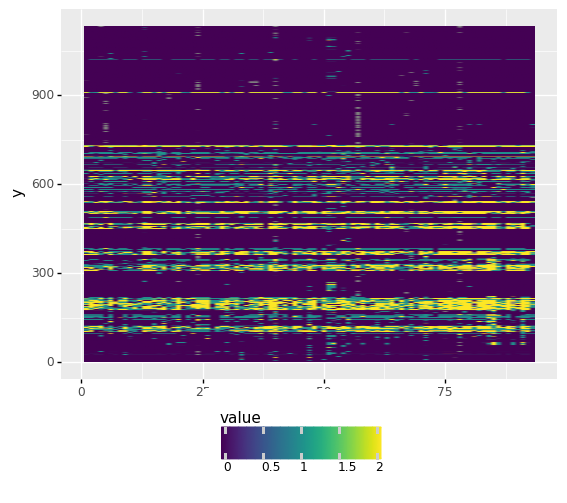

<ggplot: (345912408)>

In [286]:
ggplot(aimsnpspd,
           aes(x='i',y='y',fill='value')) + geom_raster() + \
           theme(legend_position="bottom")